# SCT analysis — magnetic_2…5 (FR0)

Единое полотно по исследованию в `COSY/sct_study/`.

**Что делает этот notebook**
- объясняет модель и физику каждого шага;
- воспроизводит анализ из уже посчитанных артефактов;
- не запускает новый COSY-трекинг;
- явно отделяет подтверждённые результаты от диагностических приближений.

**Охват**
- mapping, $\mathbf I^*$ и $\Delta\delta_{eq}$: `magnetic_2`…`magnetic_5`;
- multi-turn частицы и $C(n)$: только `magnetic_2`;
- секступольные диаграммы: геометрическая иллюстрация, не точный Twiss-фазовый анализ.

Формулы используют синтаксис `$...$` и `$$...$$`, который отображается в Jupyter/Cursor Preview.


## 0. Импорты и пути

Подключаем общий слой `py/common.py` и библиотеку mapping `map_lat_lib.py`.
Notebook можно запускать из `COSY/sct_study/` или из корня репозитория.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# Resolve study root whether cwd is repo root or sct_study
cwd = Path.cwd().resolve()
if (cwd / "py" / "common.py").is_file():
    STUDY = cwd
elif (cwd / "COSY" / "sct_study" / "py" / "common.py").is_file():
    STUDY = cwd / "COSY" / "sct_study"
else:
    STUDY = Path(r"COSY/sct_study").resolve()

PY = STUDY / "py"
sys.path.insert(0, str(PY))

from common import (  # noqa: E402
    DAT_OUT,
    PLOTS,
    STRUCTURES,
    delta_eq_theory,
    get_data,
    get_dual_model,
    lattice_length,
    load_config,
    model_summary,
    solve_currents,
    stems,
)
from analyze_phase_advance import (  # noqa: E402
    default_tunes,
    estimate_phase_advances,
    parse_lengths,
    parse_sext_strengths_from_istar,
    plot_polar,
    resultant_vector,
    walk_lattice,
)
from analyze_tracking import (  # noqa: E402
    assign_groups_from_initial,
    read_trpray,
    read_trpspi,
)

cfg = load_config()
STEMS = stems()
print("STUDY =", STUDY)
print("stems =", STEMS)
print("gamma, G =", cfg["gamma"], cfg["G"])
print("pilot tracking stem =", cfg["tracking"]["pilot_stem"])
PLOTS.mkdir(parents=True, exist_ok=True)


STUDY = C:\GIT_REPOS\SCT\COSY\sct_study
stems = ['magnetic_2', 'magnetic_3', 'magnetic_4', 'magnetic_5']
gamma, G = 1.143914 -0.142987
pilot tracking stem = magnetic_2


## 1. Физическая постановка

Частица: **дейтрон**, режим fringe **FR0** (без fringe), без FIT.

В модели есть три независимо задаваемых коэффициента семейств секступолей:

$$
\mathbf I=(SG_{x1},SG_{x2},SG_{y1}).
$$

Здесь буква $I$ — **не ток частицы** и не обязательно ток в амперах. Это вектор численных управляющих коэффициентов, которые передаются процедуре `LATTICE` в COSY и задают силы семейств SF1, SF2 и SD. Пока калибровка «коэффициент COSY → амперы источника питания» не задана, корректнее говорить **коэффициенты/настройки секступолей**, а не физические токи.

Эти три настройки изменяют три интегральные характеристики орбитальной динамики:

$$
\boldsymbol{\xi}=(\xi_x,\xi_y,\eta_1),
$$

где $\xi_x$ и $\xi_y$ — горизонтальная и вертикальная хроматичности, а $\eta_1$ — коэффициент второго порядка, используемый далее в модели удлинения пути.

Цель исследования:

1. Найти настройку $\mathbf I^*$, при которой модель предсказывает $\xi_x=\xi_y=\eta_1=0$.
2. Проверить эту настройку прямым расчётом COSY.
3. Оценить, как это влияет на $\Delta\delta_{eq}$ и спиновую динамику.

Звёздочка в $\mathbf I^*$ означает «выбранное решение задачи обнуления», а не умножение и не комплексное сопряжение.

Схема пайплайна:

```
mapping FR0 → линейная модель → I* → отдельная проверка COSY
                                  ↓
                       Δδ_eq и multi-turn анализ
```


## 2. Mapping: линейная модель отклика

Mapping-скан лежит в `COSY/src/dat/<stem>/`. Для каждой из 125 заранее рассчитанных настроек $\mathbf I$ известны $\xi_x$, $\xi_y$, $\eta_1$ и изменения спинового tune зондов.

По этим точкам строится линейная аппроксимация:

$$
\boldsymbol{\xi}=R_{\mathrm{int}}\mathbf I+\boldsymbol{\xi}_{\mathrm{natural}}.
$$

- $\mathbf I$ — три настройки семейств секступолей;
- $\boldsymbol{\xi}_{\mathrm{natural}}$ — значения при выключенных секступолях, то есть при $\mathbf I=0$;
- $R_{\mathrm{int}}$ — матрица $3\times3$. Её элемент показывает, насколько меняется одна из величин $\xi_x,\xi_y,\eta_1$ при изменении одной настройки секступолей.

Искомая настройка вычисляется из системы

$$
R_{\mathrm{int}}\mathbf I^*=-\boldsymbol{\xi}_{\mathrm{natural}}.
$$

Это обычное решение трёх линейных уравнений с тремя неизвестными. Отдельно строится аналогичная линейная модель для изменений спинового tune:

$$
\Delta\boldsymbol{\nu}_s=R_{\mathrm{spin}}\mathbf I+\Delta\boldsymbol{\nu}_{s,\mathrm{natural}}.
$$

**Что усредняется здесь:** только почти постоянные по mapping-сетке коэффициенты $\alpha_0$ и $\alpha_1$. Частицы и обороты на этом этапе не усредняются.


In [2]:
summaries = {}
for stem in STEMS:
    df = get_data(stem, "FR0")
    if df is None:
        print(stem, "NO DATA")
        continue
    s = model_summary(df)
    summaries[stem] = s
    I = np.array(s["I_star"])
    print(
        f"{stem}: n={s['n_points']}, cond={s['condition_number']:.1f}, "
        f"I*=({I[0]:+.4e}, {I[1]:+.4e}, {I[2]:+.4e}), "
        f"inside_box={s['grid_relation']['inside_axis_aligned_box']}, "
        f"min|I*-grid|={s['grid_relation']['min_distance_to_grid_point']:.4g}"
    )

rows = []
for stem, s in summaries.items():
    chrom_v = s["chrom_verify"] if isinstance(s["chrom_verify"], dict) else {}
    rows.append({
        "stem": stem,
        "cond(R_int)": s["condition_number"],
        "SGx1*": s["I_star"][0],
        "SGx2*": s["I_star"][1],
        "SGy1*": s["I_star"][2],
        "inside FR0 box": s["grid_relation"]["inside_axis_aligned_box"],
        "min|I*-grid|": s["grid_relation"]["min_distance_to_grid_point"],
        "R2 xi_x": chrom_v.get("r2_chrom_x"),
        "R2 xi_y": chrom_v.get("r2_chrom_y"),
        "R2 eta1": chrom_v.get("r2_eta_1"),
    })
pd.DataFrame(rows)


magnetic_2: n=125, cond=34.5, I*=(+4.1106e-03, -3.1840e-03, -4.0305e-03), inside_box=False, min|I*-grid|=0.004102
magnetic_3: n=125, cond=35.9, I*=(+2.7590e-02, -2.8351e-02, -2.3078e-02), inside_box=False, min|I*-grid|=0.02863
magnetic_4: n=125, cond=180.6, I*=(+1.6647e-01, -2.9818e-01, -2.2273e-01), inside_box=False, min|I*-grid|=0.3416
magnetic_5: n=125, cond=69.7, I*=(+2.2384e-01, -1.9367e-01, -6.1637e-02), inside_box=False, min|I*-grid|=0.2362


,stem,cond(R_int),SGx1*,SGx2*,SGy1*,inside FR0 box,min|I*-grid|,R2 xi_x,R2 xi_y,R2 eta1
0,magnetic_2,34.538178,0.004111,-0.003184,-0.004031,False,0.004102,1.0,1.0,1.0
1,magnetic_3,35.874824,0.027590,-0.028351,-0.023078,False,0.028627,1.0,1.0,1.0
2,magnetic_4,180.588538,0.166469,-0.298176,-0.222727,False,0.341620,1.0,1.0,1.0
3,magnetic_5,69.663430,0.223842,-0.193672,-0.061637,False,0.236156,1.0,1.0,1.0


### Как читать таблицу

#### `cond(R_int)`

`cond` — **число обусловленности** матрицы $R_{\mathrm{int}}$. Оно показывает чувствительность найденной настройки $\mathbf I^*$ к небольшим ошибкам исходных данных.

- `cond = 1` — идеальный случай;
- чем число больше, тем сильнее ошибка в $\xi_x,\xi_y,\eta_1$ может увеличиться после решения системы;
- например, `180` потенциально заметно менее устойчиво, чем `35`.

Это не вероятность и не точность в процентах. Фраза «лучше обусловлена» означает только: **численно задача для `magnetic_2` менее чувствительна к ошибкам, чем для `magnetic_4`**.

#### `inside FR0 box`

125 mapping-точек занимают ограниченный диапазон настроек $SG_{x1}$, $SG_{x2}$ и $SG_{y1}$. `inside FR0 box` проверяет, попадает ли каждая из трёх координат $\mathbf I^*$ внутрь минимального и максимального значений, реально использованных в скане.

- `True` — решение внутри исследованного диапазона;
- `False` — хотя бы одна координата снаружи.

Например, `no (SGx2 < 0)` означает: в скане $SG_{x2}$ не был отрицательным, а модель потребовала отрицательное значение. `no, far` означает, что решение не просто снаружи, а далеко от ближайшей реально рассчитанной точки.

#### `min|I*-grid|`

Это евклидово расстояние от $\mathbf I^*$ до ближайшей из 125 mapping-точек:

$$
d_{\min}=\min_k\left\|\mathbf I^*-\mathbf I_k\right\|_2.
$$

Чем меньше число, тем ближе решение к уже проверенной точке скана. Сравнивать его корректно только при одинаковых единицах и масштабе трёх коэффициентов.

#### Почему идеальная линейность не устраняет риск

$R^2\approx1$ означает: **внутри рассчитанной сетки** прямая очень хорошо описывает данные. Но $\mathbf I^*$ для всех четырёх структур находится за этой сеткой. Продолжение прямой за область измерений называется **экстраполяцией**. За пределами сетки могут проявиться нелинейные члены, которых внутри неё не видно.

При этом отдельный запуск `validate_Istar.dat` уже показал, что COSY действительно даёт близкие к нулю $\xi_x$, $\xi_y$ и $\eta_1$ в найденных точках. То есть экстраполяция здесь была проверена для этих трёх величин, но сама диагностическая метрика всё равно полезна.


## 3. Какие конфигурации сравниваются и как проверяется $\mathbf I^*$

`tag` — это просто короткое имя **набора настроек секступолей внутри одной и той же структуры**. Это не новый магнит и не новая структура.

| tag | какие настройки используются | зачем |
|---|---|---|
| `natural` | $\mathbf I=(0,0,0)$, секступоли выключены | базовый случай |
| `Istar` | найденная настройка $\mathbf I^*$ | проверка обнуления $\xi_x,\xi_y,\eta_1$ |
| `ctrl_xi_x` | точка исходной mapping-сетки с большим $|\xi_x|$ | контрольный случай с заведомо большой горизонтальной хроматичностью |
| `ctrl_xi_y` | точка с большим $|\xi_y|$ | контроль вертикальной хроматичности |
| `ctrl_eta1` | точка с большим $|\eta_1|$ | контроль импульсного члена |

Контрольные теги нужны не потому, что мы ожидаем изменения $\gamma G$ или базового спинового tune. Они позволяют сравнить орбитальный и спиновый трекинг при разных хроматических настройках той же решётки.

Два файла имеют разные роли:

- `zero_point.json` — удобная сводка расчёта Python: найденная $\mathbf I^*$, обусловленность и выбранные контрольные настройки;
- `validate_Istar.dat` — независимый прямой вывод COSY после повторного расчёта решётки именно при $\mathbf I^*$.

Следующая ячейка сравнивает предсказание линейной модели с прямым результатом COSY. Числа порядка $10^{-13}$ фактически являются нулём на уровне численной точности этого расчёта.


In [3]:
zp = {}
for stem in STEMS:
    path = DAT_OUT / stem / "zero_point.json"
    zp[stem] = json.loads(path.read_text(encoding="utf-8"))

for stem, z in zp.items():
    print("====", stem, "====")
    print("pred chrom @I*:", z["pred_chrom_at_Istar"])
    vpath = DAT_OUT / stem / "validate_Istar.dat"
    if vpath.is_file():
        vals = {}
        for line in vpath.read_text(encoding="utf-8", errors="ignore").splitlines():
            if "=" in line:
                k, v = line.split("=", 1)
                try:
                    vals[k.strip()] = float(v.strip())
                except ValueError:
                    pass
        keep = {k: vals[k] for k in vals if k.startswith(("chrom", "eta1", "dnu", "eta"))}
        print("from validate_Istar.dat:", keep)
    else:
        print("(validate_Istar.dat missing)")


==== magnetic_2 ====
pred chrom @I*: [-2.220446049250313e-16, -2.220446049250313e-16, 2.220446049250313e-16]
from validate_Istar.dat: {'chrom_x': -9.275276758026027e-13, 'chrom_y': -8.142732584409265e-13, 'dnu_x': -3.489953048774197e-10, 'dnu_y': -1.33341940267151e-09, 'dnu_z': 1.692465612102012e-11, 'eta1': -1.332267629550188e-13}
==== magnetic_3 ====
pred chrom @I*: [-4.440892098500626e-16, -4.440892098500626e-16, 0.0]
from validate_Istar.dat: {'chrom_x': -7.774152710628226e-14, 'chrom_y': -3.943471849788202e-14, 'dnu_x': -1.446809394511916e-09, 'dnu_y': -2.871908877377649e-09, 'dnu_z': 8.332501355567956e-12, 'eta1': 2.109423746787797e-15}
==== magnetic_4 ====
pred chrom @I*: [1.7763568394002505e-15, -3.552713678800501e-15, -4.440892098500626e-16]
from validate_Istar.dat: {'chrom_x': -8.832701021246228e-13, 'chrom_y': -8.796923516908407e-13, 'dnu_x': -1.130844706764833e-08, 'dnu_y': -9.97440455230425e-09, 'dnu_z': -8.537615059367454e-12, 'eta1': -2.34257058195908e-14}
==== magnetic_5

## 4. Рабочие точки $Q_x$, $Q_y$ и $\nu_s$

Здесь проверяется one-turn map одной и той же структуры при разных настройках секступолей.

В текущих результатах для каждого `stem` величины $Q_x$, $Q_y$, $\nu_s$ и $\gamma G$ действительно одинаковы для всех `tag` в показанной точности. Это ожидаемо:

- секступоль на центральной орбите не меняет линейную фокусировку первого порядка, поэтому базовые $Q_x$ и $Q_y$ не сдвигаются;
- $\gamma G$ определяется энергией и аномальным магнитным моментом дейтрона, а они между тегами не меняются;
- базовый $\nu_s$ центральной частицы поэтому также остаётся тем же.

Таблица оставлена как **проверка**, что изменение тегов не внесло неожиданный сдвиг рабочей точки. Она не утверждает, что это разные рабочие точки. Эти числа относятся к one-turn map центральной частицы, а не к индивидуальным частотам частиц из multi-turn трекинга.


In [4]:
wp_rows = []
for stem in STEMS:
    path = DAT_OUT / stem / "working_point.json"
    data = json.loads(path.read_text(encoding="utf-8"))
    for tag, pt in data.get("points", {}).items():
        wp_rows.append({
            "stem": stem,
            "tag": tag,
            "Qx": pt.get("Qx"),
            "Qy": pt.get("Qy"),
            "NU_s": pt.get("NU_s") or pt.get("nu_s"),
            "gammaG": pt.get("gammaG") or pt.get("gamma_G"),
        })
wp_df = pd.DataFrame(wp_rows)
wp_df


,stem,tag,Qx,Qy,NU_s,gammaG
0,magnetic_2,natural,0.446284,0.476682,0.163565,-0.163565
1,magnetic_2,Istar,0.446284,0.476682,0.163565,-0.163565
2,magnetic_2,ctrl_xi_x,0.446284,0.476682,0.163565,-0.163565
3,magnetic_2,ctrl_xi_y,0.446284,0.476682,0.163565,-0.163565
4,magnetic_2,ctrl_eta1,0.446284,0.476682,0.163565,-0.163565
5,magnetic_3,natural,0.709522,0.688151,0.163565,-0.163565
6,magnetic_3,Istar,0.709522,0.688151,0.163565,-0.163565
7,magnetic_3,ctrl_xi_x,0.709522,0.688151,0.163565,-0.163565
8,magnetic_3,ctrl_xi_y,0.709522,0.688151,0.163565,-0.163565
9,magnetic_3,ctrl_eta1,0.709522,0.688151,0.163565,-0.163565


## 5. Теоретический $\Delta\delta_{eq}$

В коде используется диагностическая формула:

$$
\Delta\delta_{eq}=
\frac{\gamma^2}{\gamma^2\alpha_0-1}
\left[
\frac{1}{2}\delta_m^2\eta_1-
\frac{\pi}{L}\left(\varepsilon_x\xi_x+\varepsilon_y\xi_y\right)
\right].
$$

Обозначения:

- $\varepsilon_x$ и $\varepsilon_y$ — выбранные диагностические эмиттансы;
- $\xi_x$ и $\xi_y$ — хроматичности;
- $\delta_m$ — масштаб относительного разброса импульса;
- $\eta_1$ — коэффициент второго порядка;
- $L$ — длина кольца;
- $\alpha_0$ — momentum compaction первого порядка.

При $\xi_x=\xi_y=\eta_1=0$ правая часть равна нулю по самому определению формулы. Поэтому прохождение кривой через ноль — проверка реализации формулы, а не независимое физическое подтверждение.


In [5]:
rows = []
for stem in STEMS:
    df = get_data(stem, "FR0")
    m = get_dual_model(df)
    alpha0 = float(df["alpha_0"].mean())
    L = lattice_length(stem)
    gamma = float(cfg["gamma"])
    for tag, I in {
        "natural": np.zeros(3),
        "Istar": np.array(summaries[stem]["I_star"]),
    }.items():
        chrom = m["R_int"] @ I + m["int_nat"]
        for sname, sc in cfg["emittance_scenarios"].items():
            dde = delta_eq_theory(
                chrom[0], chrom[1], chrom[2], alpha0,
                eps_x=sc["eps_x"], eps_y=sc["eps_y"], delta_m=sc["delta_m"],
                L=L, gamma=gamma,
            )
            rows.append({
                "stem": stem, "tag": tag, "scenario": sname,
                "xi_x": chrom[0], "xi_y": chrom[1], "eta1": chrom[2],
                "delta_eq": dde,
            })
dde_df = pd.DataFrame(rows)
dde_df.pivot_table(index=["stem", "scenario"], columns="tag", values="delta_eq")


tag                         Istar       natural
stem       scenario                            
magnetic_2 D_only   -2.079660e-24 -9.532610e-09
           X_only   -1.113134e-23 -9.228135e-08
           Y_only   -1.113134e-23 -9.262616e-08
magnetic_3 D_only    0.000000e+00 -7.739410e-09
           X_only   -1.720486e-23 -1.447261e-07
           Y_only   -1.720486e-23 -1.451067e-07
magnetic_4 D_only    3.147102e-24 -6.882172e-09
           X_only    6.170243e-23 -1.906553e-07
           Y_only   -1.234049e-22 -1.905141e-07
magnetic_5 D_only   -7.639690e-25 -6.441771e-09
           X_only   -2.874598e-23 -2.347050e-07
           Y_only   -5.749197e-23 -2.376321e-07

### magnetic_2

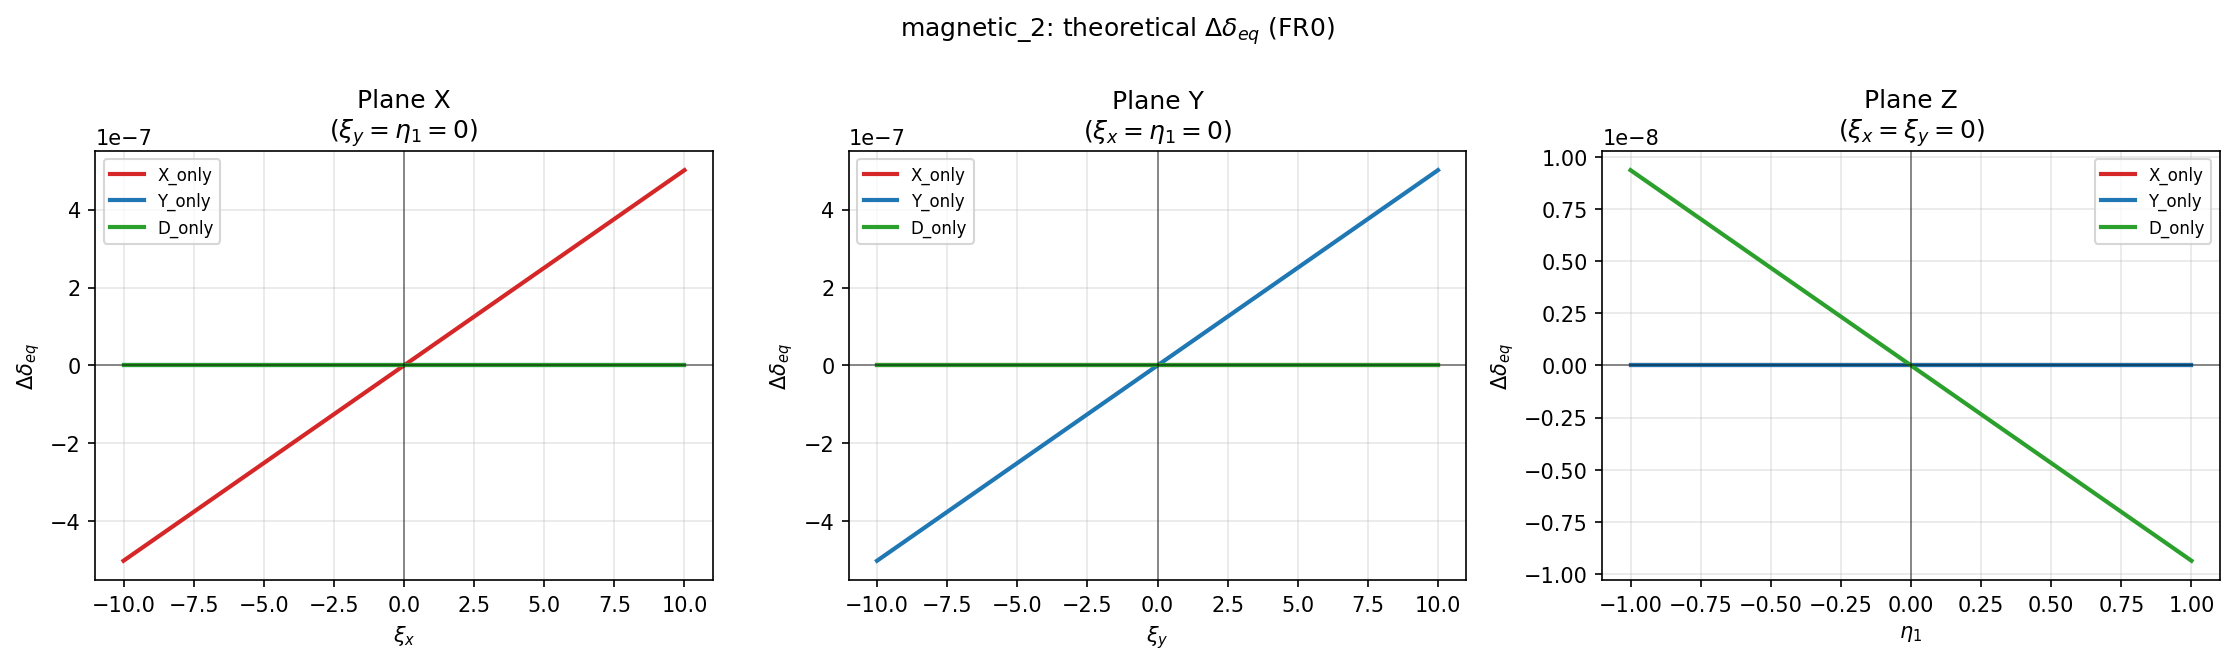

### magnetic_3

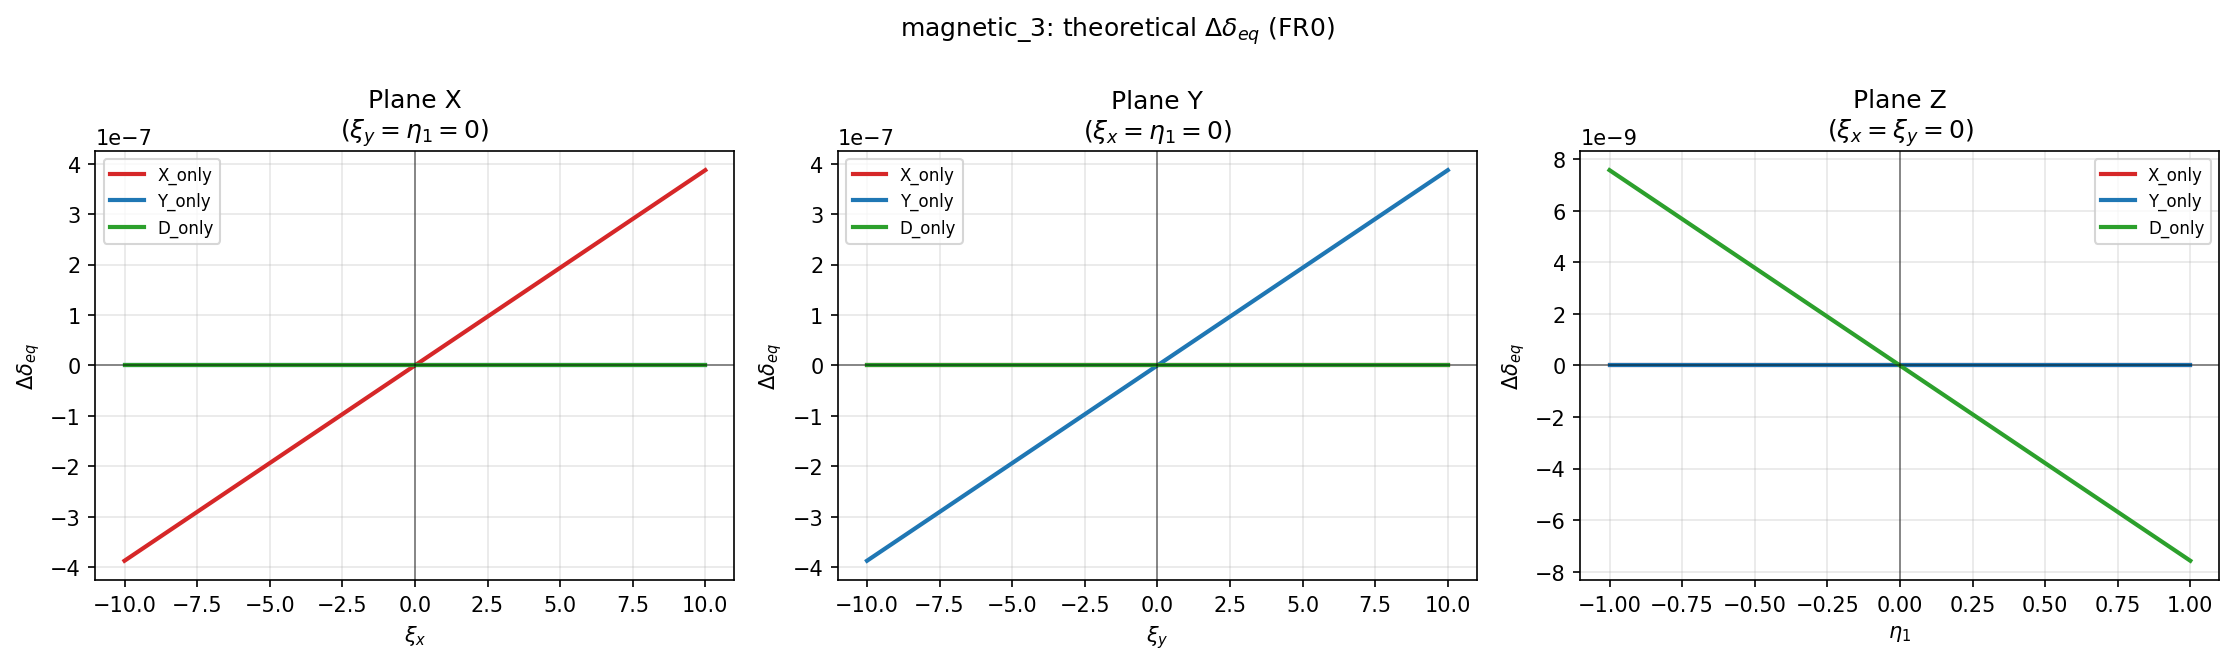

### magnetic_4

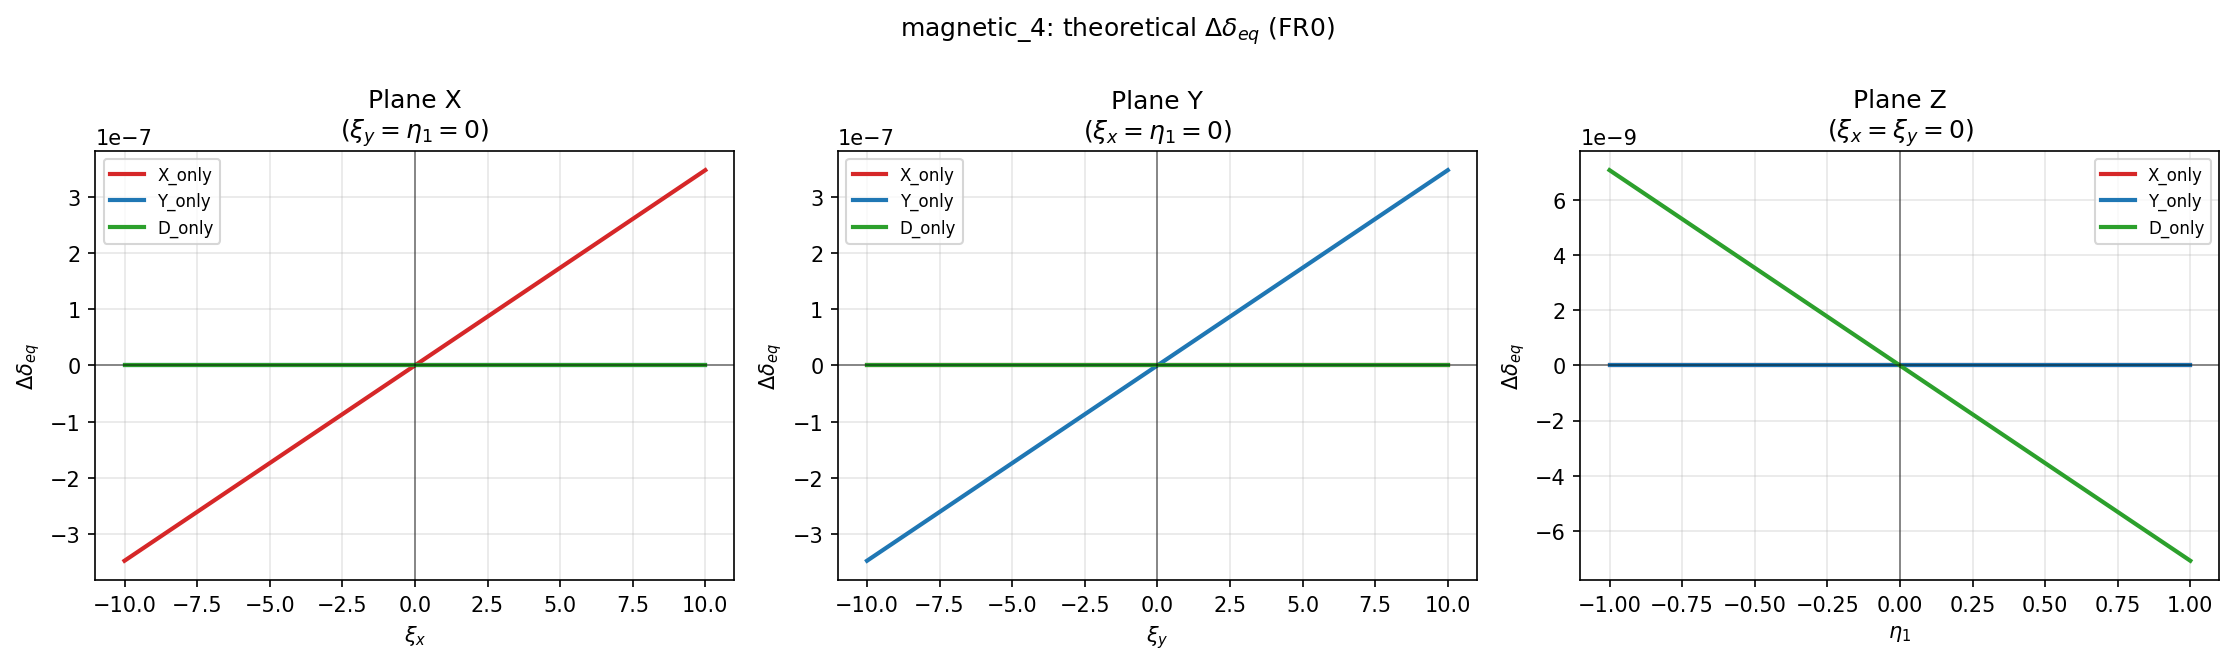

### magnetic_5

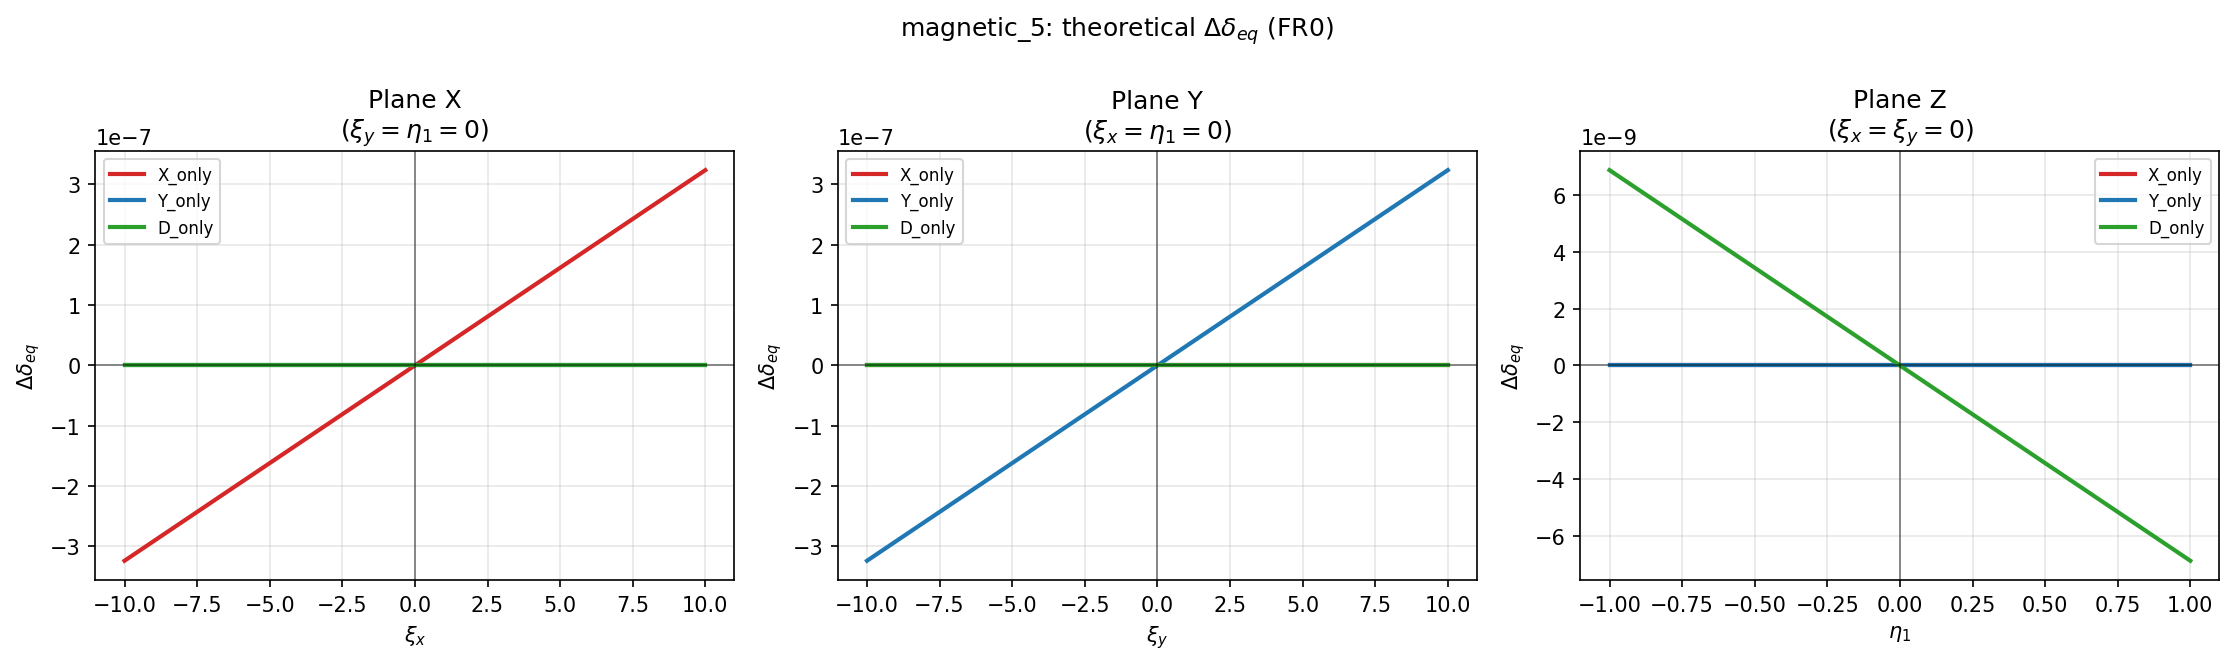

In [6]:
for stem in STEMS:
    p = PLOTS / f"{stem}_delta_eq_panels.png"
    if p.is_file():
        display(Markdown(f"### {stem}"))
        display(Image(filename=str(p)))


## 6. Геометрические диаграммы расположения секступолей

Здесь под «магнитом» имеется в виду **каждый отдельный экземпляр секступоля** в решётке. `SF1`, `SF2` и `SD` — три семейства; в каждом семействе несколько секступолей с одинаковым коэффициентом настройки.

### Что фактически вычисляет текущий код

Для центра каждого секступоля известна продольная координата $s_j$. Код назначает ему угол

$$
\mu_{x,j}^{\mathrm{proxy}}=2\pi Q_x\frac{s_j}{C},
\qquad
\mu_{y,j}^{\mathrm{proxy}}=2\pi Q_y\frac{s_j}{C},
$$

где $C$ — длина кольца. Это предположение о **равномерном накоплении фазы по длине**. Радиус стрелки равен $|K_{2,j}|$; отрицательный $K_{2,j}$ изображается поворотом на $\pi$.

Пунктирная сумма на рисунке вычисляется как

$$
\Sigma_{\mathrm{proxy}}=\sum_j |K_{2,j}|e^{i\mu_{j}^{\mathrm{signed}}}.
$$

### Важное ограничение: это не точная физическая фаза

Истинная бетатронная фаза определяется оптической функцией $\beta(s)$:

$$
\psi_x(s)=\int_0^s\frac{ds'}{\beta_x(s')},
\qquad
\psi_y(s)=\int_0^s\frac{ds'}{\beta_y(s')}.
$$

Она накапливается неравномерно. Кроме того, вклад секступоля в конкретный resonance driving term зависит не только от $K_2$, но также от длины элемента, $\beta_x$, $\beta_y$ и комбинации фаз выбранного резонанса.

Следовательно, текущие диаграммы корректно показывают:

- порядок и продольное расположение секступолей;
- семейство и знак настройки;
- геометрическую proxy-сумму при явно указанном приближении.

Но по ним **нельзя подтверждать физическую компенсацию секступольных ударов**. Для такой проверки нужны Twiss-функции и выбор конкретного resonance driving term. Поэтому результат ниже следует читать как иллюстрацию расположения, а не как доказанный фазовый анализ.


magnetic_2: 10 MH; |Σ|_x=0.01527, |Σ|_y=0.01457


### magnetic_2 — plane x

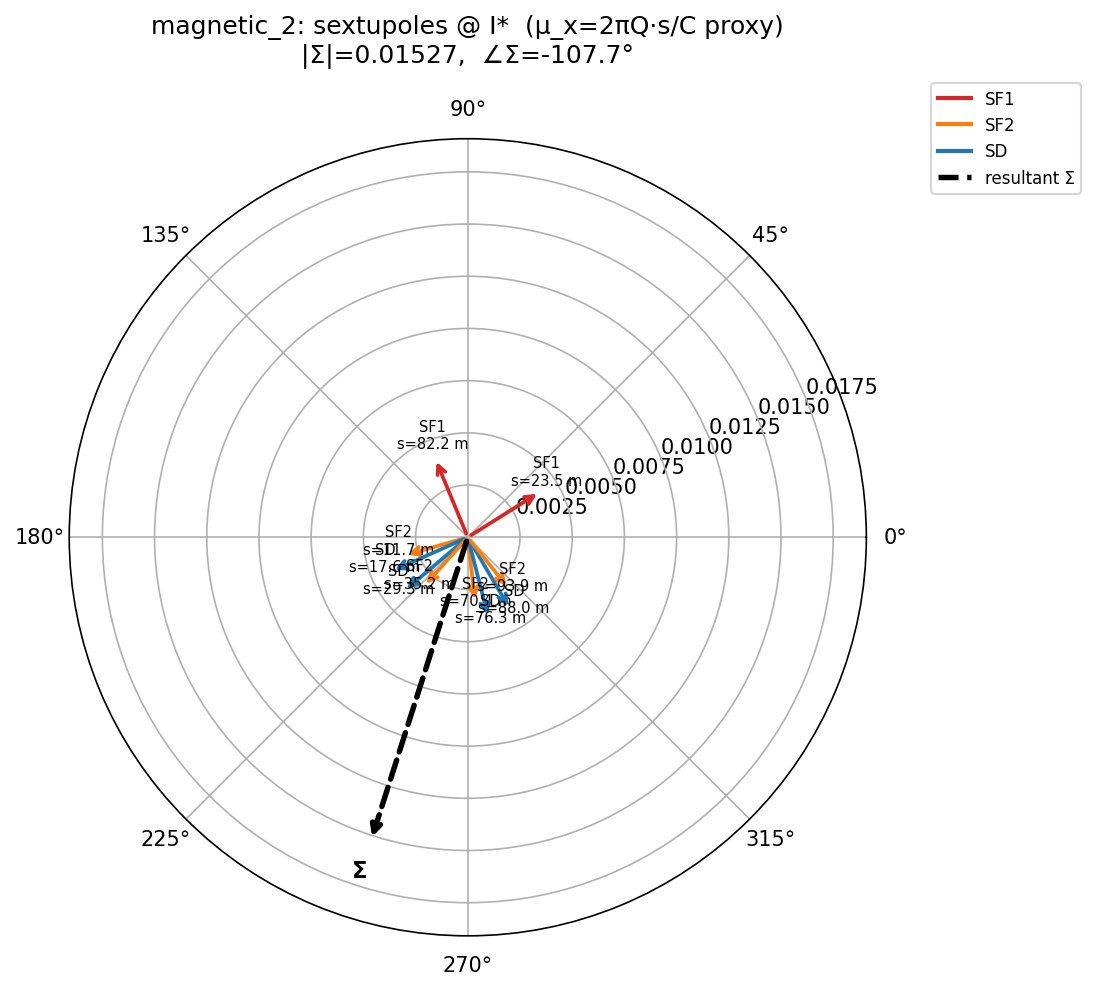

### magnetic_2 — plane y

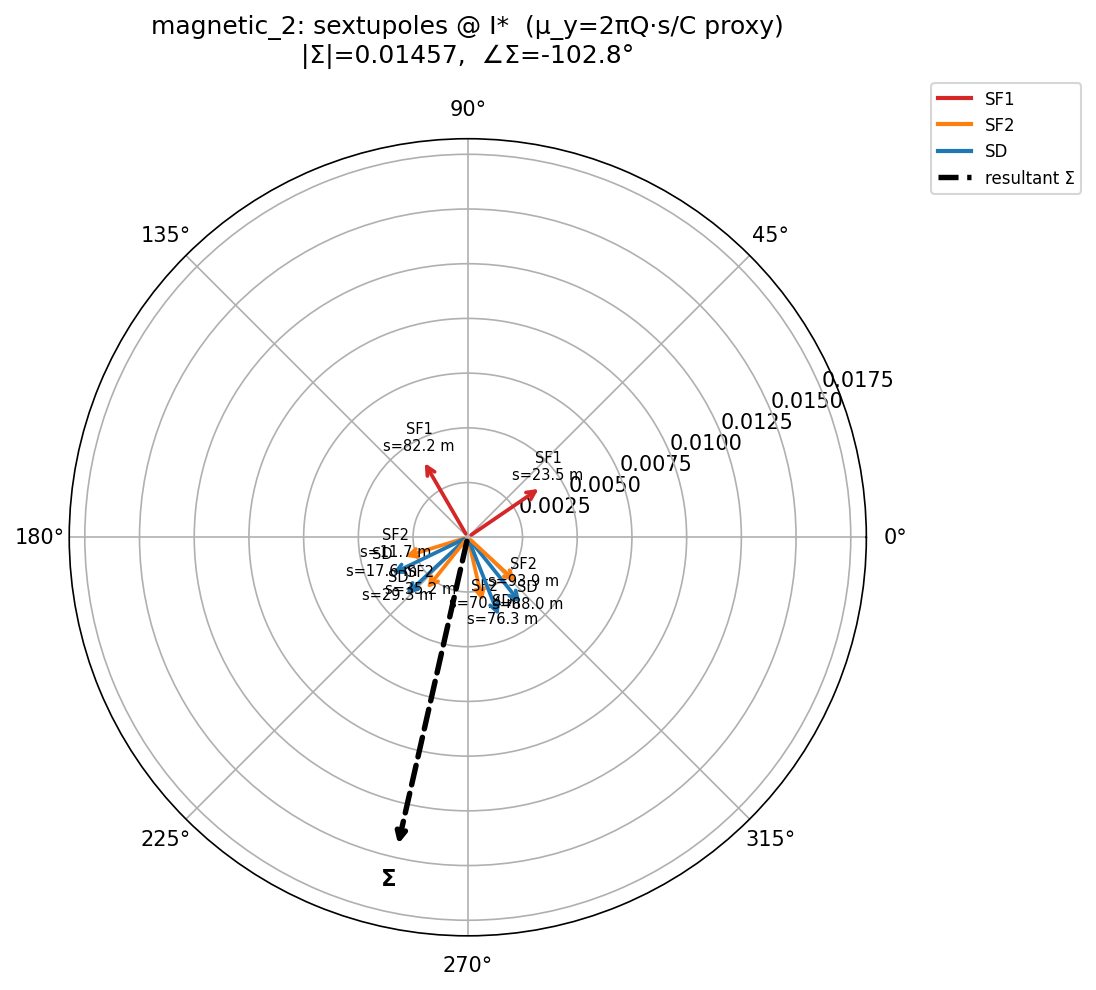

magnetic_3: 15 MH; |Σ|_x=0.08451, |Σ|_y=0.09117


### magnetic_3 — plane x

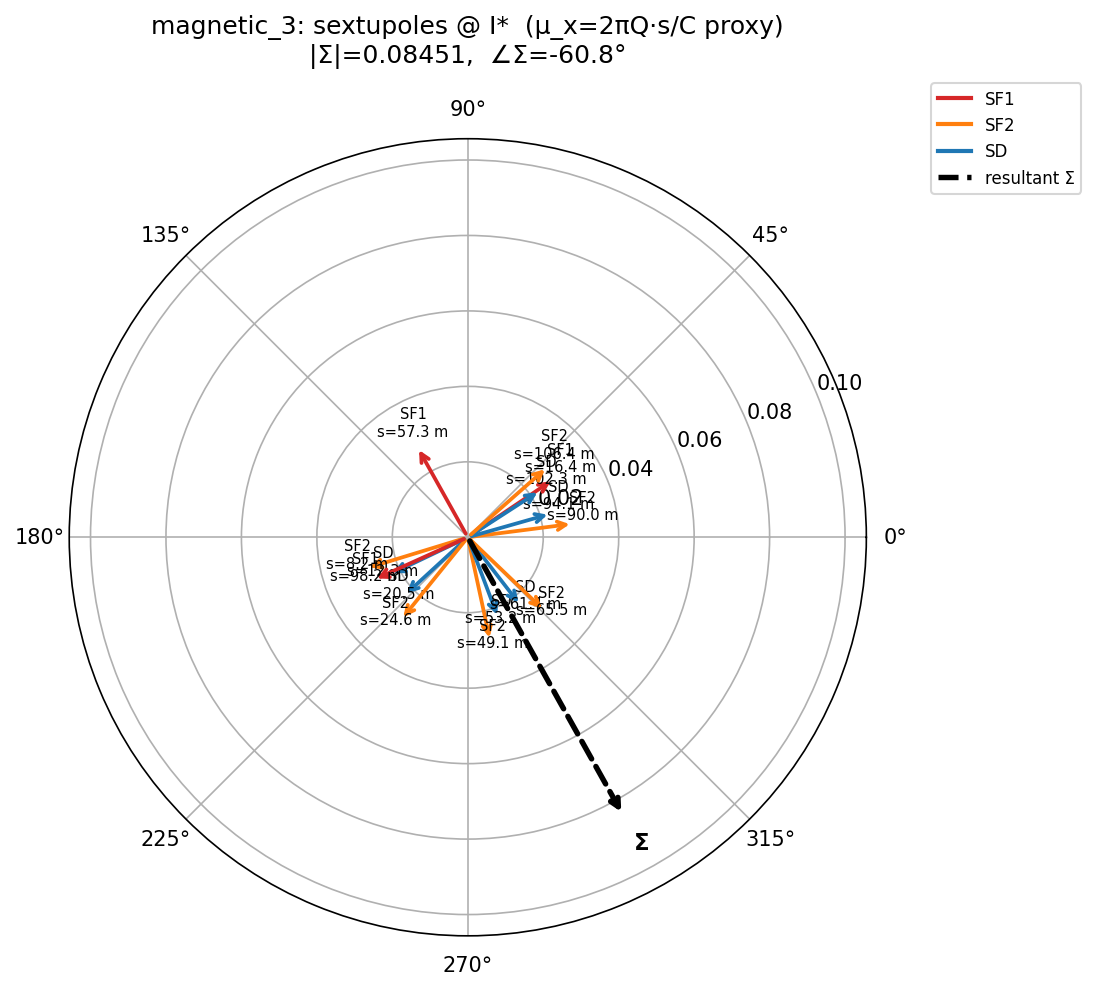

### magnetic_3 — plane y

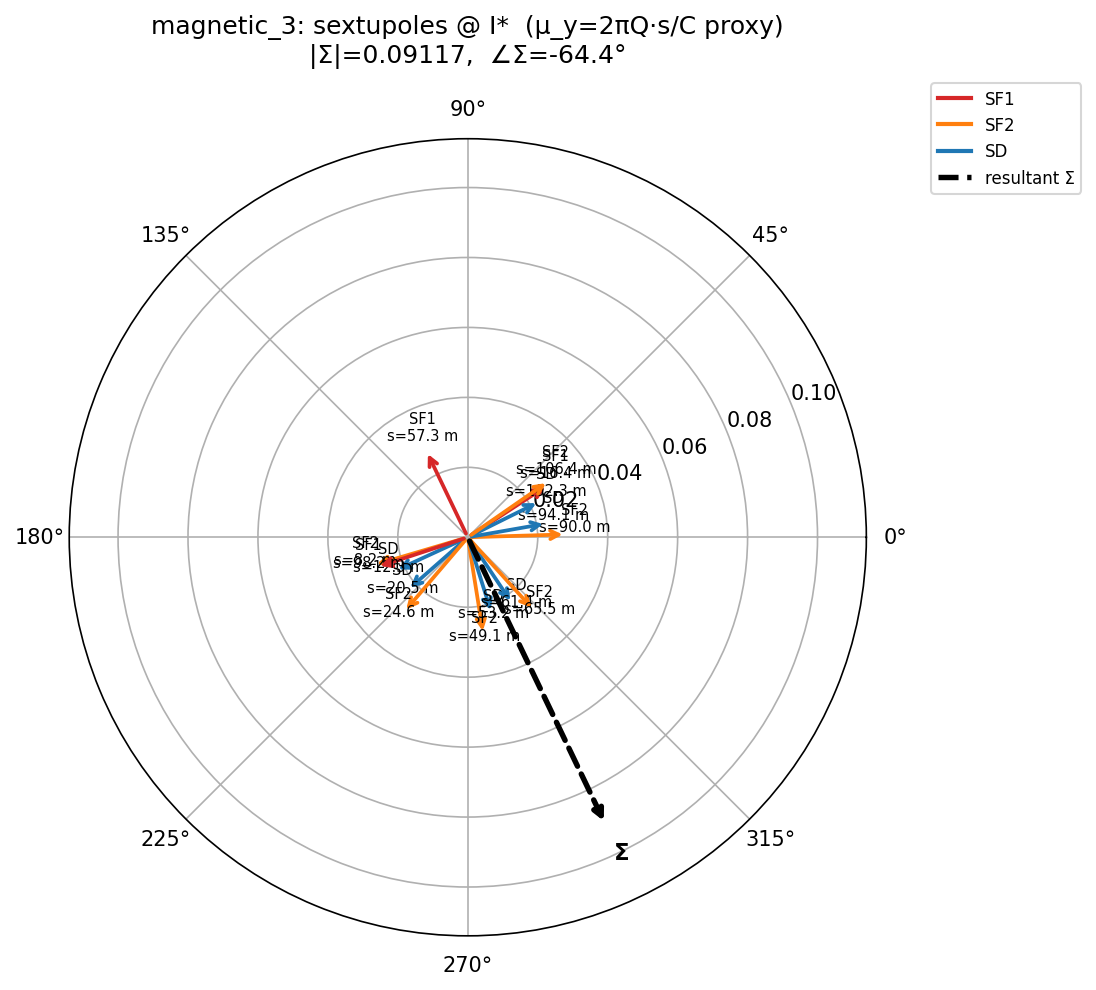

magnetic_4: 20 MH; |Σ|_x=0.2824, |Σ|_y=0.3531


### magnetic_4 — plane x

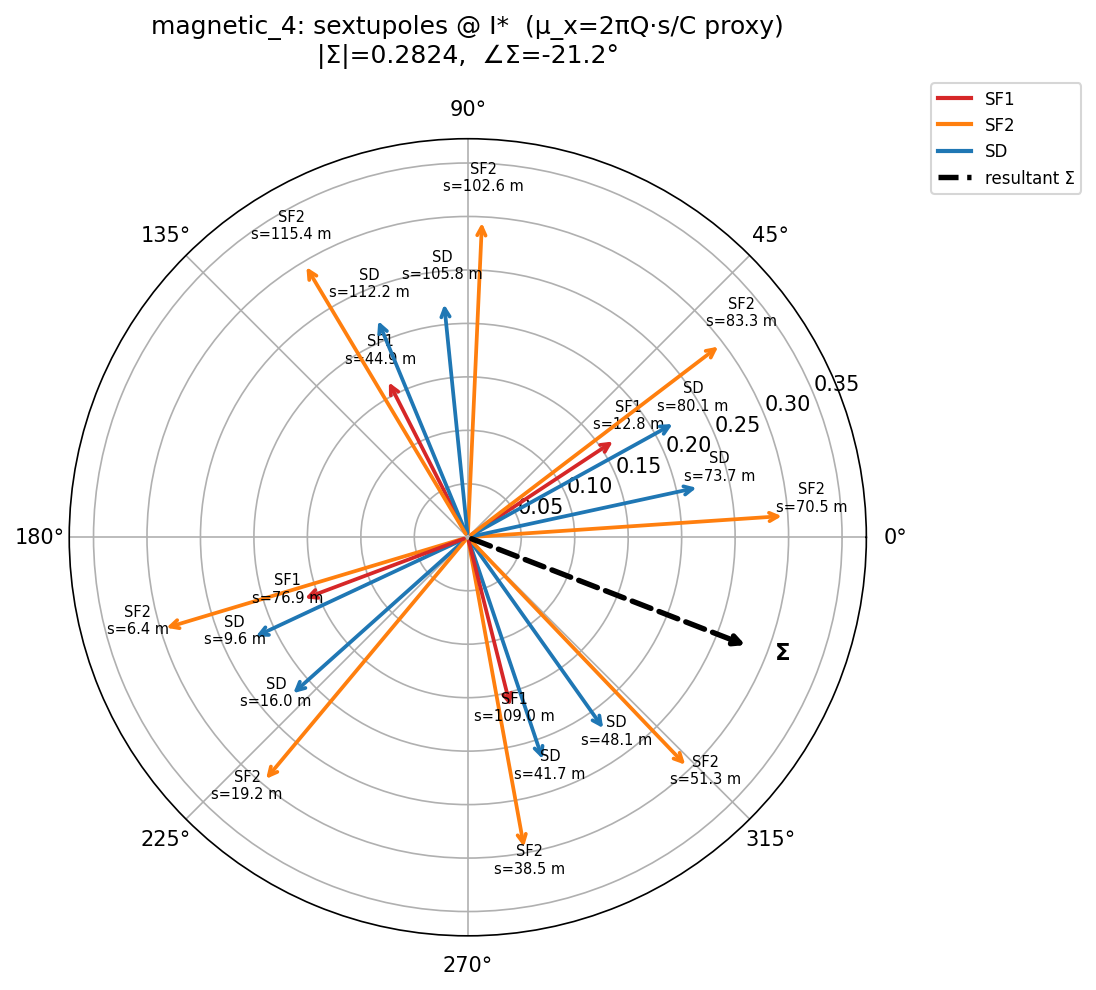

### magnetic_4 — plane y

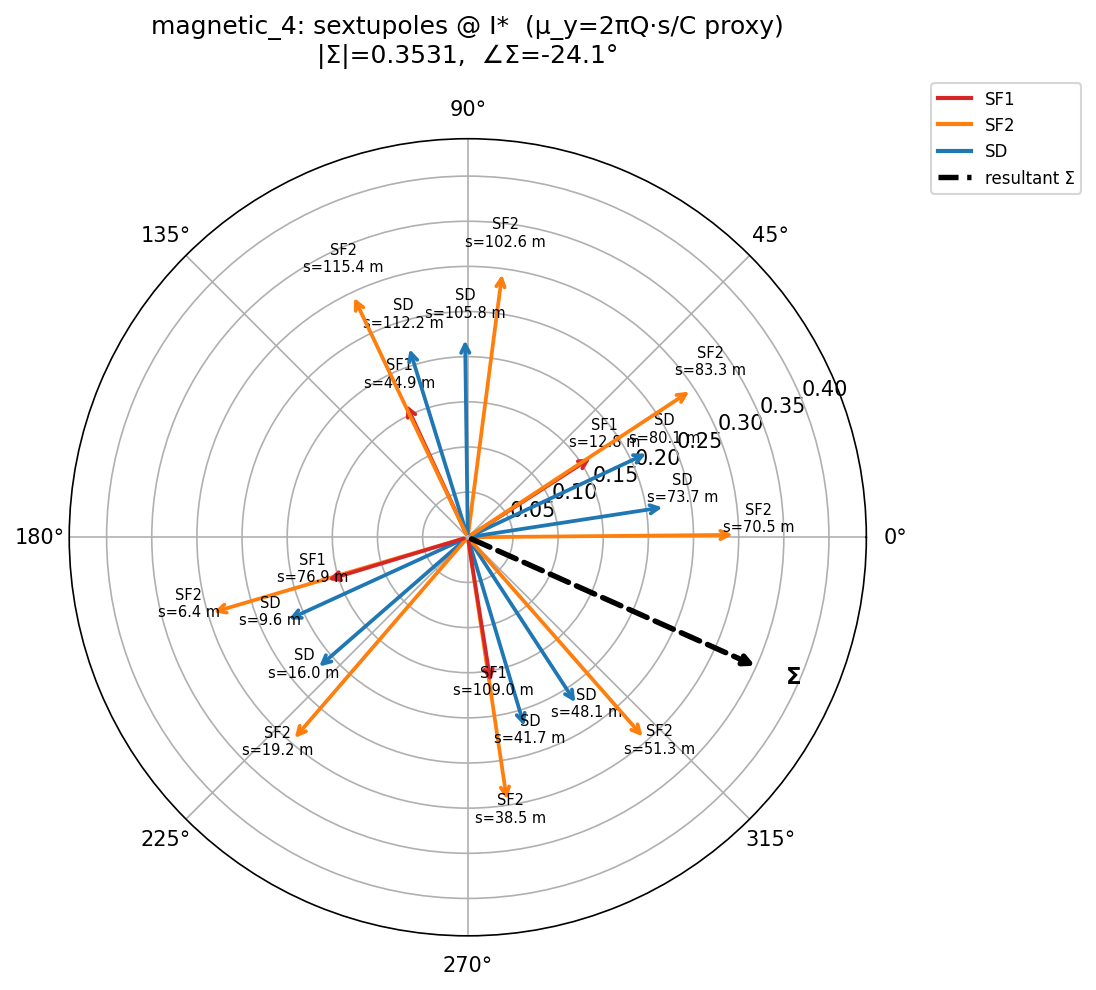

magnetic_5: 25 MH; |Σ|_x=1.302, |Σ|_y=1.316


### magnetic_5 — plane x

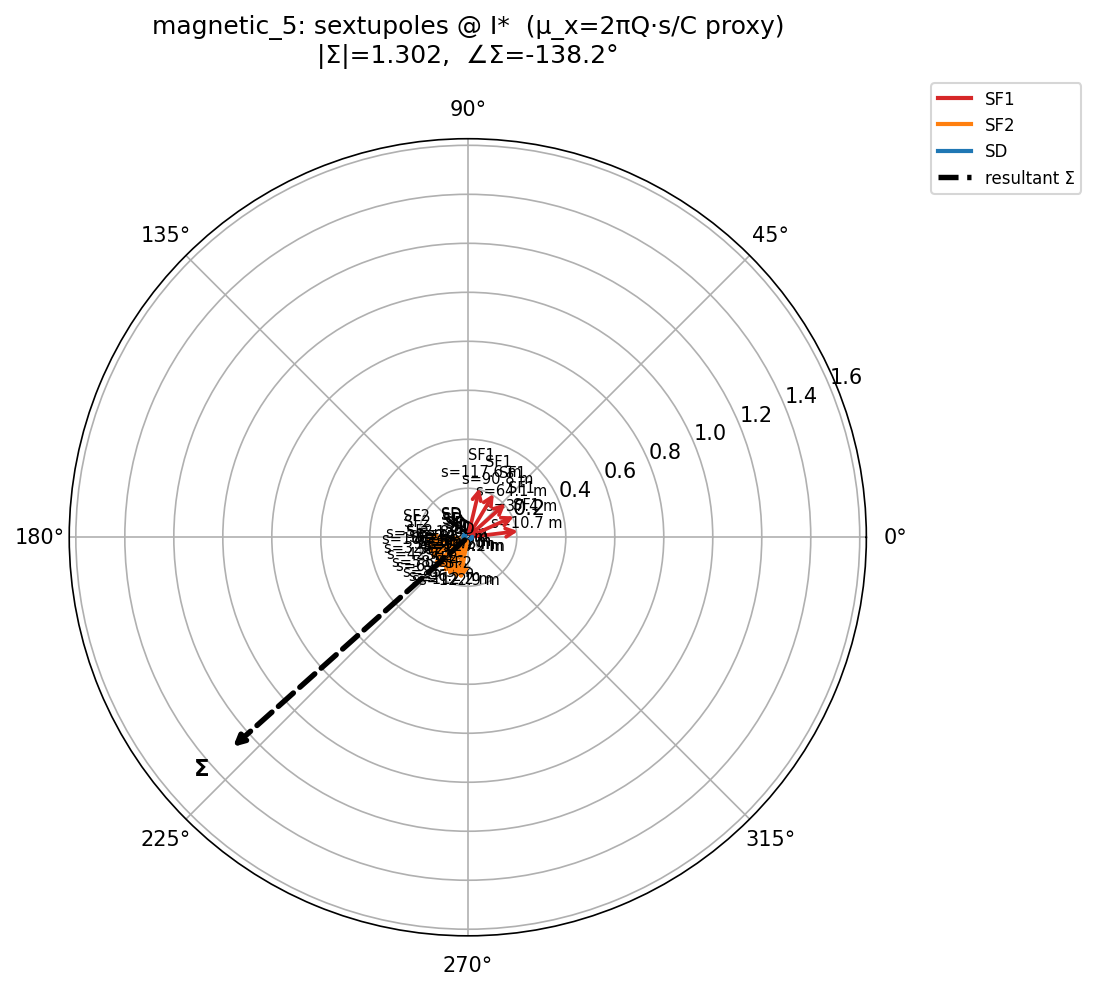

### magnetic_5 — plane y

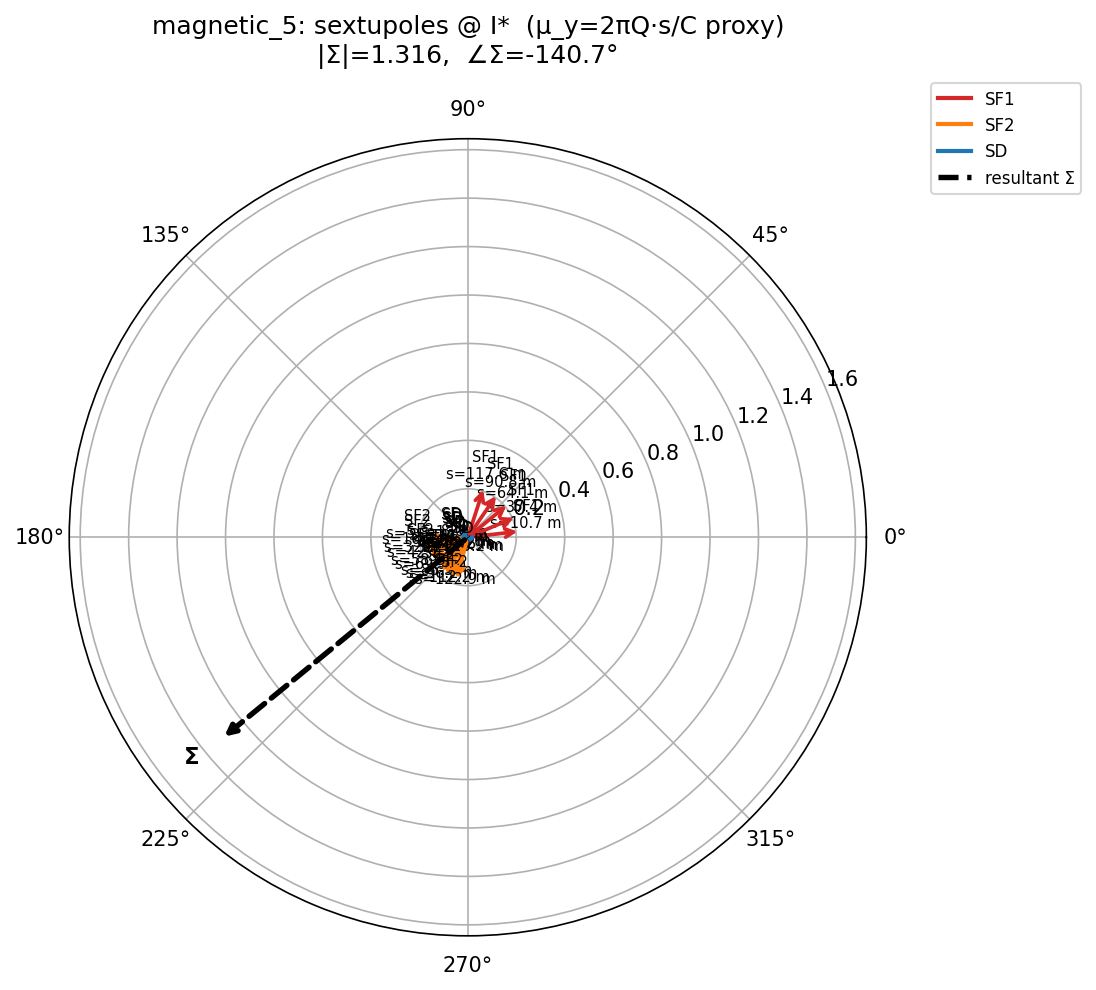

,stem,n_MH,Qx,Qy,|Σ|_x,∠Σ_x [deg],|Σ|_y,∠Σ_y [deg]
0,magnetic_2,10,0.446284,0.476682,0.015269,-107.702016,0.014570,-102.777444
1,magnetic_3,15,0.709522,0.688151,0.084514,-60.800380,0.091168,-64.390589
2,magnetic_4,20,0.928547,0.911708,0.282418,-21.218390,0.353127,-24.097975
3,magnetic_5,25,0.241657,0.227440,1.301552,-138.241619,1.316287,-140.698311


In [7]:
phase_info = {}
for stem in STEMS:
    text = (STRUCTURES / stem / f"{stem}.fox").read_text(encoding="utf-8")
    lengths = parse_lengths(text)
    elements = walk_lattice(text, lengths)
    df = get_data(stem, "FR0")
    m = get_dual_model(df)
    Istar = solve_currents(m["R_int"], m["int_nat"], np.zeros(3))
    strengths = parse_sext_strengths_from_istar(Istar)
    Qx, Qy = default_tunes(stem)
    elements = estimate_phase_advances(elements, Qx, Qy)
    sexts = []
    for el in elements:
        if el["kind"] != "MH" or el["family"] not in strengths:
            continue
        e = dict(el)
        e["K2"] = strengths[el["family"]]
        sexts.append(e)
    res_x = resultant_vector(sexts, "x")
    res_y = resultant_vector(sexts, "y")
    phase_info[stem] = {"n": len(sexts), "Qx": Qx, "Qy": Qy, "res_x": res_x, "res_y": res_y}
    px = plot_polar(stem, sexts, "x", res_x)
    py = plot_polar(stem, sexts, "y", res_y)
    print(f"{stem}: {len(sexts)} MH; |Σ|_x={res_x['magnitude']:.4g}, |Σ|_y={res_y['magnitude']:.4g}")
    display(Markdown(f"### {stem} — plane x"))
    display(Image(filename=str(px)))
    display(Markdown(f"### {stem} — plane y"))
    display(Image(filename=str(py)))

pd.DataFrame([
    {
        "stem": s,
        "n_MH": v["n"],
        "Qx": v["Qx"],
        "Qy": v["Qy"],
        "|Σ|_x": v["res_x"]["magnitude"],
        "∠Σ_x [deg]": v["res_x"]["angle_deg"],
        "|Σ|_y": v["res_y"]["magnitude"],
        "∠Σ_y [deg]": v["res_y"]["angle_deg"],
    }
    for s, v in phase_info.items()
])


## 7. Multi-turn: ансамбль частиц (только `magnetic_2`)

### Какие частицы запускались

Шаблон `fox/_template_track.fox` создаёт диагностический набор лучей:

1. reference-луч с нулевыми начальными орбитальными координатами;
2. группа **X**: начальное $X$ меняется от $-10^{-3}$ до $10^{-3}$ м, остальные отклонения нулевые;
3. группа **Y**: аналогично меняется только $Y$;
4. группа **D**: меняется только относительное отклонение импульса $D$.

Начальный спин каждого физического луча задан как $\mathbf S=(0,1,0)$.

`smoke` содержит 200 оборотов, `full` — 2000. Состояние сохраняется каждые 5% полного числа оборотов, поэтому оба файла содержат примерно по 21 временному срезу.

### Какие файлы используются

| файл | содержание |
|---|---|
| `*_PRAY.dat` | только начальные условия |
| `*_TRPRAY.dat` | орбитальные координаты $X,A,Y,B,T,D$ |
| `*_TRPSPI.dat` | компоненты спина $S_x,S_y,S_z$ |
| `*_analysis.json` | результат последующей обработки Python |

### Что именно усредняется

Для каждого луча первые 20% сохранённых срезов отбрасываются. Затем координата $D$ усредняется **по оставшимся оборотам этого же луча**:

$$
\overline D_i=\frac{1}{N_t}\sum_{n\ge n_1}D_i(n).
$$

После этого из каждого среднего вычитается среднее reference-луча:

$$
\Delta D_i=\overline D_i-\overline D_{\mathrm{ref}}.
$$

В прежнем коде эта величина названа `delta_eq`, но строго это только **multi-turn proxy** для равновесного сдвига импульса. Это не прямое вычисление теоретической формулы $\Delta\delta_{eq}$ из главы 5.


In [8]:
pilot = cfg["tracking"]["pilot_stem"]
kind = "full"
tags = ["natural", "Istar", "ctrl_xi_x", "ctrl_xi_y", "ctrl_eta1"]

orb = read_trpray(DAT_OUT / pilot / f"track_Istar_{kind}_TRPRAY.dat")
spi = read_trpspi(DAT_OUT / pilot / f"track_Istar_{kind}_TRPSPI.dat")
groups = assign_groups_from_initial(orb)
turns = np.sort(orb["turn"].unique())
n1 = turns[int(0.2 * len(turns))]
print(f"files: {len(orb)} orbit rows, {len(spi)} spin rows")
print(f"unique turns: {turns[:3]} ... {turns[-3:]}  (N={len(turns)})")
print(f"transient cut turn n1 = {n1}")
print("group counts:", {g: sum(1 for v in groups.values() if v == g) for g in ("ref", "X", "Y", "D")})

t0 = orb["turn"].min()
init = orb[orb["turn"] == t0].copy()
init["group"] = init["ray"].map(groups)
init[["ray", "group", "X", "Y", "D"]].head(30)


files: 609 orbit rows, 609 spin rows
unique turns: [  0 100 200] ... [1800 1900 2000]  (N=21)
transient cut turn n1 = 400
group counts: {'ref': 5, 'X': 8, 'Y': 8, 'D': 8}


,ray,group,X,Y,D
0,0,ref,0.00000,0.00000,0.000000
1,1,ref,0.00000,0.00000,0.000000
2,2,X,-0.00100,0.00000,0.000000
3,3,X,-0.00075,0.00000,0.000000
4,4,X,-0.00050,0.00000,0.000000
5,5,X,-0.00025,0.00000,0.000000
6,6,ref,0.00000,0.00000,0.000000
7,7,X,0.00025,0.00000,0.000000
8,8,X,0.00050,0.00000,0.000000
9,9,X,0.00075,0.00000,0.000000


## 8. Спиновая фаза, частота и когерентность $C(n)$

### Шаг 1. Фаза отдельного спина

Начальный спин направлен вдоль оси $y$. Если он вращается вокруг приблизительно вертикальной устойчивой оси, его проекция на плоскость $XZ$ описывает окружность. Код определяет угол этой проекции:

$$
\phi_i(n)=\operatorname{atan2}\!\left(S_{x,i}(n),S_{z,i}(n)\right).
$$

`atan2` возвращает угол в диапазоне от $-\pi$ до $\pi$. Операция `unwrap` пытается убрать искусственные скачки на границе этого диапазона, добавляя или вычитая $2\pi$.

### Шаг 2. Что код называет `dnu_s`

После transient код проводит прямую через фазу:

$$
\phi_i(n)\approx a_i n+b_i,
$$

и сохраняет

$$
\nu_{i}^{\mathrm{fit}}=\frac{a_i}{2\pi}.
$$

Но это значение сейчас **нельзя надёжно интерпретировать как индивидуальный spin tune** по двум причинам:

1. Для `full` спин сохраняется только раз в 100 оборотов, а ожидаемый spin tune около $0.1636$ оборота спина за один оборот частицы. Между соседними записями спин делает примерно 16 оборотов; `unwrap` не знает, сколько полных оборотов было пропущено. Это временной алиасинг.
2. В коде из наклона каждого луча не вычитается наклон reference-луча, хотя поле названо `dnu_s`.

Следовательно, показанное ниже распределение `dnu_s` — распределение **алиасированных наклонов сохранённой фазы**, а не доказанное распределение физических спиновых частот. Чтобы получить индивидуальный spin tune, нужно сохранять спин значительно чаще либо применять метод, учитывающий известный базовый tune и фазу относительно reference.

### Шаг 3. Фазовая когерентность

Для каждого сохранённого оборота вычисляется относительная фаза

$$
\Delta\phi_i(n)=\phi_i(n)-\phi_{\mathrm{ref}}(n).
$$

Затем каждый угол представляется единичным комплексным вектором и эти векторы усредняются:

$$
C(n)=\left|\frac{1}{N}\sum_{i=1}^{N}e^{\,i\Delta\phi_i(n)}\right|.
$$

Читать эту формулу можно так:

1. $e^{i\Delta\phi_i}$ — стрелка единичной длины с углом $\Delta\phi_i$;
2. если все стрелки направлены одинаково, их средняя длина равна 1;
3. если направления распределены по кругу, они взаимно компенсируются и средняя длина близка к 0.

Поэтому:

- $C(n)=1$ — спины имеют одинаковую относительную фазу в сохранённый момент;
- $C(n)\approx0$ — относительные фазы сильно разошлись.

$C(n)$ описывает **фазовую** согласованность только в редкие сохранённые моменты. Сам по себе он не доказывает одинаковость частот.

### Чего текущий анализ не делает

- не получает надёжные индивидуальные spin tune из-за редкого сохранения;
- не извлекает орбитальные $Q_{x,i}$ и $Q_{y,i}$ из $X(n)$ и $Y(n)$;
- не использует согласованный (`matched`) ансамбль пучка;
- предполагает, что плоскость $XZ$ подходит для определения фазы.


In [9]:
analyses = {}
for tag in tags:
    path = DAT_OUT / pilot / f"track_{tag}_{kind}_analysis.json"
    if path.is_file():
        analyses[tag] = json.loads(path.read_text(encoding="utf-8"))
        print(
            f"loaded {tag}: C_final={analyses[tag]['C_final']:.4g}, "
            f"dnu_rms={analyses[tag]['dnu_rms']:.4g}, "
            f"dde_rms_X={analyses[tag]['delta_eq_rms_by_group']['X']:.4g}"
        )
    else:
        print("MISSING", path)


loaded natural: C_final=0.0009192, dnu_rms=0.002171, dde_rms_X=6.479e-09
loaded Istar: C_final=0.0004617, dnu_rms=0.002171, dde_rms_X=5.713e-13
loaded ctrl_xi_x: C_final=0.01238, dnu_rms=0.00217, dde_rms_X=6.869e-08
loaded ctrl_xi_y: C_final=0.01238, dnu_rms=0.00217, dde_rms_X=6.869e-08
loaded ctrl_eta1: C_final=0.008574, dnu_rms=0.002267, dde_rms_X=3.895e-08


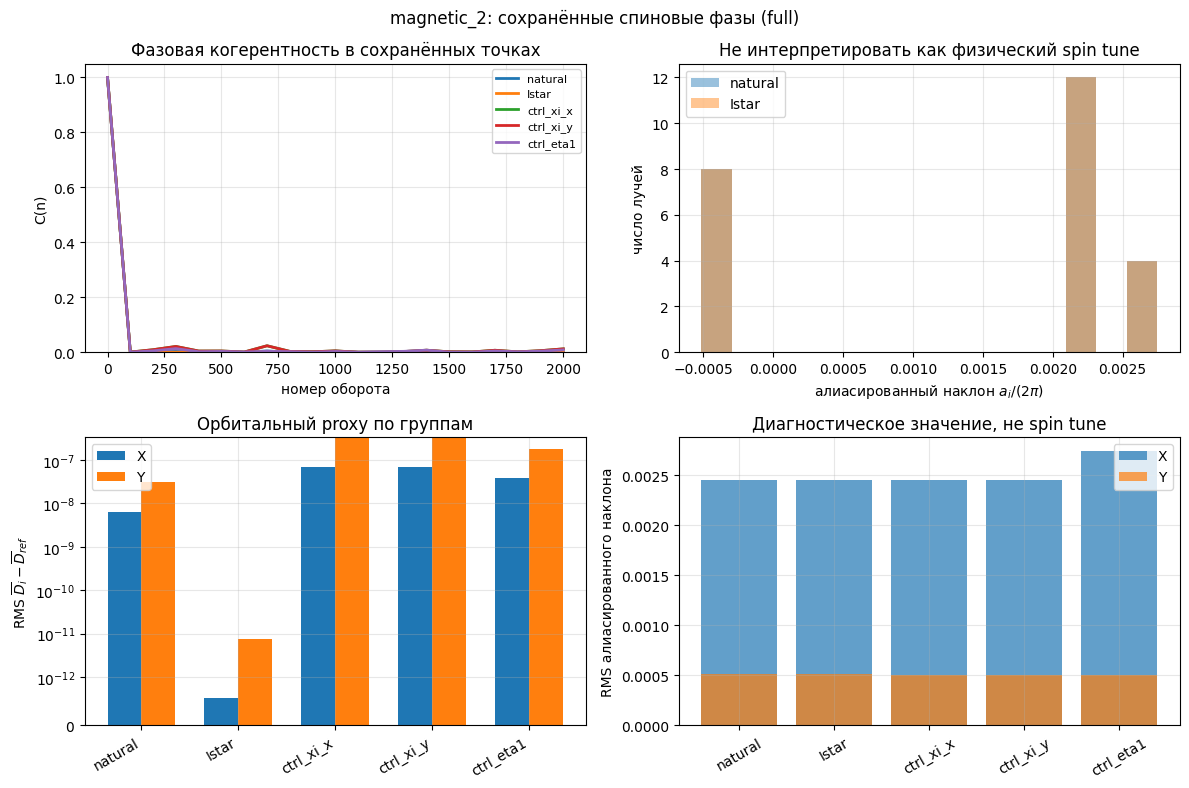

saved C:\GIT_REPOS\SCT\COSY\sct_study\plots\magnetic_2_analysis_notebook_spin_full.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"{pilot}: сохранённые спиновые фазы ({kind})")

ax = axes[0, 0]
for tag, data in analyses.items():
    ax.plot(data["turns"], data["C"], lw=2, label=tag)
ax.set_xlabel("номер оборота")
ax.set_ylabel("C(n)")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
ax.set_title("Фазовая когерентность в сохранённых точках")

ax = axes[0, 1]
for tag, color in [("natural", "C0"), ("Istar", "C1")]:
    if tag not in analyses:
        continue
    vals = [d["dnu_s"] for d in analyses[tag]["dnu_s"] if d["group"] != "ref"]
    ax.hist(vals, bins=15, alpha=0.45, label=tag, color=color)
ax.set_xlabel(r"алиасированный наклон $a_i/(2\pi)$")
ax.set_ylabel("число лучей")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Не интерпретировать как физический spin tune")

ax = axes[1, 0]
width = 0.35
tags_plot = list(analyses)
x = np.arange(len(tags_plot))
ax.bar(x - width / 2, [analyses[t]["delta_eq_rms_by_group"]["X"] for t in tags_plot], width, label="X")
ax.bar(x + width / 2, [analyses[t]["delta_eq_rms_by_group"]["Y"] for t in tags_plot], width, label="Y")
ax.set_xticks(x, tags_plot, rotation=30, ha="right")
ax.set_ylabel(r"RMS $\overline{D}_i-\overline{D}_{ref}$")
ax.set_yscale("symlog", linthresh=1e-12)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Орбитальный proxy по группам")

ax = axes[1, 1]
ax.bar(tags_plot, [analyses[t]["dnu_rms_by_group"]["X"] for t in tags_plot], alpha=0.7, label="X")
ax.bar(tags_plot, [analyses[t]["dnu_rms_by_group"]["Y"] for t in tags_plot], alpha=0.7, label="Y")
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("RMS алиасированного наклона")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Диагностическое значение, не spin tune")

fig.tight_layout()
out = PLOTS / f"{pilot}_analysis_notebook_spin_{kind}.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("saved", out)


In [11]:
data = analyses["Istar"]
per = pd.DataFrame(data["per_ray"])
dnu = pd.DataFrame(data["dnu_s"])
tab = per.merge(dnu, on=["ray", "group"], how="left")
print(
    f"D_ref={data['D_ref']}, transient_cut_turn={data['transient_cut_turn']}, "
    f"C_final={data['C_final']}"
)
tab.sort_values(["group", "ray"])


D_ref=0.0, transient_cut_turn=400.0, C_final=0.0004616813926889627


,ray,group,Dbar,delta_eq,X0,Y0,D0,dnu_s
20,20,D,2.196361e-05,2.196361e-05,0.00000,0.00000,-0.000100,0.002113
21,21,D,1.647263e-05,1.647263e-05,0.00000,0.00000,-0.000075,0.002113
22,22,D,1.098167e-05,1.098167e-05,0.00000,0.00000,-0.000050,0.002113
23,23,D,5.490781e-06,5.490781e-06,0.00000,0.00000,-0.000025,0.002114
25,25,D,-5.490637e-06,-5.490637e-06,0.00000,0.00000,0.000025,0.002114
26,26,D,-1.098109e-05,-1.098109e-05,0.00000,0.00000,0.000050,0.002114
27,27,D,-1.647133e-05,-1.647133e-05,0.00000,0.00000,0.000075,0.002114
28,28,D,-2.196131e-05,-2.196131e-05,0.00000,0.00000,0.000100,0.002114
2,2,X,1.252416e-12,1.252416e-12,-0.00100,0.00000,0.000000,0.002747
3,3,X,8.287287e-13,8.287287e-13,-0.00075,0.00000,0.000000,0.002747


### Как читать результат пилота

Для `magnetic_2` / `full`:

- при `Istar` RMS величины $\overline D_i-\overline D_{ref}$ для групп X/Y падает примерно на четыре порядка относительно `natural`;
- группа D почти не меняется;
- $C(n)$ в сохранённых точках при этом не улучшается на `Istar`.

Корректный вывод ограничен этим наблюдением: обнуление хроматических коэффициентов сильно уменьшает орбитальный proxy для X/Y, но не улучшает рассчитанную фазовую метрику данного диагностического ансамбля.

По текущим `TRPSPI` нельзя делать количественный вывод о разбросе индивидуальных spin tune: временное сохранение слишком редкое и вызывает алиасинг. Столбцы `dnu_s` в старых JSON оставлены для воспроизводимости, но в этом notebook больше не трактуются как физические частоты.


## 9. Smoke vs Full — почему файлы «похожи»

- `PRAY`: идентичны (одни и те же стартовые лучи).
- `TRPRAY`/`TRPSPI`: число строк близко, потому что шаг записи `NINT(NTURN·0.05)` масштабируется с `NTURN`.
- Физический горизонт разный: последние turn = 200 vs 2000.


In [12]:
for tag in ["Istar"]:
    for kind_ in ("smoke", "full"):
        for suf in ("PRAY", "TRPRAY", "TRPSPI"):
            p = DAT_OUT / pilot / f"track_{tag}_{kind_}_{suf}.dat"
            if not p.is_file():
                continue
            size = p.stat().st_size
            if suf == "PRAY":
                print(f"{p.name}: {size} bytes")
            else:
                df = read_trpray(p) if suf == "TRPRAY" else read_trpspi(p)
                tmax = int(df["turn"].max()) if len(df) else None
                print(f"{p.name}: {size} bytes, rows={len(df)}, turn_max={tmax}")


track_Istar_smoke_PRAY.dat: 4524 bytes
track_Istar_smoke_TRPRAY.dat: 66547 bytes, rows=609, turn_max=200
track_Istar_smoke_TRPSPI.dat: 39107 bytes, rows=609, turn_max=200
track_Istar_full_PRAY.dat: 4524 bytes
track_Istar_full_TRPRAY.dat: 66547 bytes, rows=609, turn_max=2000
track_Istar_full_TRPSPI.dat: 39107 bytes, rows=609, turn_max=2000


## 10. Сводка: что установлено, а что пока нет

**Подтверждено расчётом**

1. Линейная модель находит $\mathbf I^*$, а отдельный запуск COSY при этой настройке даёт $\xi_x$, $\xi_y$ и $\eta_1$ около нуля.
2. В multi-turn данных `magnetic_2` величина $\overline D_i-\overline D_{ref}$ для X/Y-групп сильно уменьшается при `Istar`.
3. $C(n)$ показывает фазовую согласованность спинов в сохранённых временных срезах.

**Не подтверждено текущими данными**

1. Индивидуальные физические spin tune: `TRPSPI` сохраняется слишком редко, поэтому линейный fit фазы алиасирован.
2. Орбитальные частоты отдельных лучей $Q_{x,i}$ и $Q_{y,i}$: они не извлекались.
3. Физическая фазовая компенсация секступолей: диаграмма использует геометрический угол $2\pi Qs/C$, а не Twiss-фазу и resonance driving terms.

**Дополнительные ограничения**

- $\mathbf I^*$ находится вне исходной mapping-сетки, хотя прямая проверка COSY для $\xi_x$, $\xi_y$, $\eta_1$ успешна;
- `fACCLEN=141` не совпадает с использованной геометрической длиной кольца;
- трекинг выполнен только для `magnetic_2` и для диагностического, а не matched-ансамбля.


In [13]:
summary_rows = []
for tag, data in analyses.items():
    summary_rows.append({
        "tag": tag,
        "C_final": data["C_final"],
        "RMS orbital proxy X": data["delta_eq_rms_by_group"]["X"],
        "RMS orbital proxy Y": data["delta_eq_rms_by_group"]["Y"],
        "RMS orbital proxy D": data["delta_eq_rms_by_group"]["D"],
        "RMS aliased phase slope X": data["dnu_rms_by_group"]["X"],
        "RMS aliased phase slope Y": data["dnu_rms_by_group"]["Y"],
        "RMS aliased phase slope D": data["dnu_rms_by_group"]["D"],
    })
pd.DataFrame(summary_rows).set_index("tag")


,C_final,RMS orbital proxy X,RMS orbital proxy Y,RMS orbital proxy D,RMS aliased phase slope X,RMS aliased phase slope Y,RMS aliased phase slope D
tag,,,,,,,
natural,0.000919,6.479108e-09,3.058859e-08,0.000015,0.002450,0.000512,0.002114
Istar,0.000462,5.712933e-13,7.588125e-12,0.000015,0.002450,0.000512,0.002114
ctrl_xi_x,0.012385,6.868757e-08,3.225313e-07,0.000015,0.002450,0.000507,0.002111
ctrl_xi_y,0.012385,6.868757e-08,3.225313e-07,0.000015,0.002450,0.000507,0.002111
ctrl_eta1,0.008574,3.894724e-08,1.807004e-07,0.000015,0.002747,0.000509,0.002113
